(aiyagari_egm)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 使用内生网格法的Aiyagari模型

```{contents} Contents
:depth: 2
```

除了基础 Anaconda 中包含的内容外，我们还需要安装 QuantEcon 的 Python 库和 JAX。

In [1]:
!pip install quantecon jax

## 概述

本讲座结合了宏观经济学中两种重要的计算方法：

1. **Aiyagari模型** {cite}`Aiyagari1994` —— 一个具有不完全市场的异质性主体模型
2. **内生网格法**（EGM） {cite}`Carroll2006` —— 一种求解动态规划问题的高效算法

在 {doc}`标准 Aiyagari 讲座 <aiyagari>` 中，我们使用离散化和值函数迭代来求解家庭问题。

然后我们使用有限马尔可夫链的平稳分布，在给定的一组价格下计算总资本。

在本讲座中，我们采用不同的方法：

1. 我们使用**内生网格法**，通过欧拉方程和线性插值来求解家庭问题。
2. 我们通过**模拟**来计算总资本，而不是使用代数技术（后者仅适用于有限情形）。

这些修改使得求解方法更快、更灵活，尤其是在处理更复杂的模型时。

我们在整个讲座中使用 [JAX](https://jax.readthedocs.io)，这样 EGM 算子、求解器和模拟都是 JIT 编译且向量化的。

### 参考文献

本讲座的主要参考文献是：

* 我们的 {doc}`前一个 Aiyagari 讲座 <aiyagari>`，介绍了关键思想
* {cite}`Aiyagari1994`，介绍了经济模型
* {cite}`Carroll2006`，介绍了内生网格法
* {cite}`Ljungqvist2012` 的第 18 章，提供了教科书式的处理


### 预备知识

我们使用以下导入：

In [2]:
import quantecon as qe
import matplotlib.pyplot as plt
import matplotlib as mpl
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"
mpl.font_manager.fontManager.addfont(FONTPATH)
plt.rcParams['font.family'] = ['Source Han Serif SC']
import jax
import jax.numpy as jnp
import numpy as np
from typing import NamedTuple
from functools import partial
from scipy.optimize import bisect

我们将在 JAX 中使用 64 位浮点数以提高精度。

In [3]:
jax.config.update("jax_enable_x64", True)

## 经济

该经济由家庭和一个代表性厂商组成。

### 家庭

无限期生存的家庭面临特异性收入冲击和借贷约束。

典型家庭面临的储蓄问题是

$$
    \max \mathbb E \sum_{t=0}^{\infty} \beta^t u(c_t)
$$

约束条件为

$$
    a_{t+1} + c_t \leq w z_t + (1 + r) a_t
    \quad
    c_t \geq 0,
    \quad \text{and} \quad
    a_t \geq -B
$$

其中

* $c_t$ 是当期消费
* $a_t$ 是资产
* $z_t$ 是劳动收入的外生部分（随机就业状态）
* $w$ 是工资率
* $r$ 是利率
* $B$ 是主体被允许借入的最大金额

外生过程 $\{z_t\}$ 遵循一个具有随机矩阵 $\Pi$ 的有限状态马尔可夫链。

最优内部消费选择满足欧拉方程

$$
    u'(c) = \beta \mathbb{E_z} [(1 + r) u'(c')]
$$

（我们用 $'$ 符号同时表示导数和未来值，这并不理想，但方便且常见。）

用资产来表示，即

$$
    u'(w z + (1 + r) a - a') 
    = \beta (1 + r) \sum_{z'} u'(w z' + (1 + r) a' - s(a', z')) \Pi(z, z') 
$$

其中 $s$ 是最优储蓄策略函数。


### 厂商

厂商在规模报酬不变的条件下，通过雇用资本和劳动来生产产出。

代表性厂商的产出为

$$
Y = A K^{\alpha} N^{1 - \alpha}
$$

其中

* $A$ 和 $\alpha$ 是参数，满足 $A > 0$ 和 $\alpha \in (0, 1)$
* $K$ 是总资本
* $N$ 是总劳动供给（标准化为 1）

这些参数存储在以下 namedtuple 中：

In [4]:
class Firm(NamedTuple):
    A: float = 1.0    # 全要素生产率
    N: float = 1.0    # 总劳动供给
    α: float = 0.33   # 资本份额
    δ: float = 0.05   # 折旧率

根据厂商的一阶条件，资本的反需求为

```{math}
:label: aiy_egm_rgk

r = A \alpha  \left( \frac{N}{K} \right)^{1 - \alpha} - \delta
```

In [5]:
def r_given_k(K, firm):
    """
    资本的反需求曲线。
    """
    A, N, α, δ = firm
    return A * α * (N / K)**(1 - α) - δ

作为 $r$ 的函数的均衡工资率为

```{math}
:label: aiy_egm_wgr

w(r) = A  (1 - \alpha)  (A \alpha / (r + \delta))^{\alpha / (1 - \alpha)}
```

In [6]:
def r_to_w(r, firm):
    """
    与给定利率 r 相关的均衡工资。
    """
    A, N, α, δ = firm
    return A * (1 - α) * (A * α / (r + δ))**(α / (1 - α))

### 均衡

一个**平稳理性预期均衡（SREE）**由价格和策略组成，满足：

* 家庭在给定价格下进行优化
* 厂商在给定价格下最大化利润
* 市场出清：资本总供给等于资本总需求
* 总量在时间上保持恒定

## 使用 EGM 的实现

### 家庭原语

首先我们设置家庭参数和网格：

In [7]:
class Household(NamedTuple):
    β: float            # 贴现因子
    a_grid: jnp.ndarray # 资产网格
    z_grid: jnp.ndarray # 外生状态
    Π: jnp.ndarray      # 转移矩阵

def create_household(β=0.96,                      # 贴现因子
                     Π=[[0.9, 0.1], [0.1, 0.9]],  # 马尔可夫链
                     z_grid=[0.1, 1.0],           # 外生状态
                     a_min=1e-10, a_max=50.0,     # 资产网格
                     a_size=200):
    """
    创建一个具有自定义网格的 Household namedtuple。
    """
    a_grid = jnp.linspace(a_min, a_max, a_size)
    z_grid, Π = map(jnp.array, (z_grid, Π))
    return Household(β=β, a_grid=a_grid, z_grid=z_grid, Π=Π)

对于效用，我们假设 $u(c) = \log(c)$，这给出 $u'(c) = 1/c$ 和 $(u')^{-1}(x) = 1/x$。

In [8]:
@jax.jit
def u_prime(c):
    return 1 / c

@jax.jit
def u_prime_inv(x):
    return 1 / x

这是价格的 namedtuple：

In [9]:
class Prices(NamedTuple):
    r: float = 0.01  # 利率
    w: float = 1.0   # 工资

### EGM 算子

EGM 的关键洞见是通过外生地选择资产网格并直接从欧拉方程计算消费值，来避免求根。

使用 EGM 的 Coleman-Reffett 算子工作原理如下：

1. 从表示在外生（下一期）资产网格 $\{a_i\}$ 上的消费策略 $\sigma$ 开始。
2. 对于每个资产水平 $a_i$ 和当前就业状态 $z_j$：
   - 计算欧拉方程的右侧：
     $$\text{RHS} = \beta (1 + r) \sum_{z'} \Pi(z_j, z') \, u'(\sigma(a_i, z'))$$
   - 使用逆边际效用得到当期消费：
     $$c_{ij} = (u')^{-1}(\text{RHS})$$
   - 从预算约束恢复隐含的当期资产水平：
     $$a_{ij} = \frac{c_{ij} + a_i - w z_j}{1 + r}$$
3. 通过插值 $(a_{ij}, c_{ij})$ 在原始资产网格上重构新策略 $K\sigma$，并处理借贷约束绑定的情形。

整个操作可以很好地向量化，因此我们将其编写为一个 JIT 编译的函数，并在就业状态上使用 `vmap`：

In [10]:
@jax.jit
def K_egm(σ, household, prices):
    """
    使用 EGM 的 Coleman-Reffett 算子，用于 Aiyagari 模型。

    这里 σ[i, j] 是当下一期资产为 a_grid[i]
    且当前就业状态为 z_grid[j] 时的消费。
    """
    β, a_grid, z_grid, Π = household
    r, w = prices
    z_size = len(z_grid)

    # 关于下一期冲击的期望 E[u'(c(a', z')) | z]
    Eu_prime = (Π @ u_prime(σ).T).T                       # (a_size, z_size)

    # 欧拉方程 -> 内生网格上的消费
    c_endo = u_prime_inv(β * (1 + r) * Eu_prime)          # (a_size, z_size)

    # 隐含的当期资产：a = (c + a' - w z) / (1 + r)
    a_endo = (c_endo + a_grid[:, None] - w * z_grid[None, :]) / (1 + r)

    # 为每个就业状态插值回外生网格
    def interp_policy(j):
        # 当今日资产低于内生网格时，借贷约束
        # 绑定，因此家庭储蓄 a_grid[0] 并消费
        # 当期收入的其余部分。
        return jnp.where(
            a_grid < a_endo[0, j],
            w * z_grid[j] + (1 + r) * a_grid - a_grid[0],
            jnp.interp(a_grid, a_endo[:, j], c_endo[:, j])
        )

    σ_new = jax.vmap(interp_policy)(jnp.arange(z_size))    # (z_size, a_size)
    return σ_new.T                                        # (a_size, z_size)

### 求解家庭问题

我们通过迭代 EGM 算子直至收敛来求解最优策略。

求解器完全 JIT 编译，并使用 `jax.lax.while_loop` 进行迭代：

In [11]:
@jax.jit
def solve_household(household, prices, tol=1e-6, max_iter=10_000):
    """
    通过迭代 EGM 算子求解家庭问题。

    返回最优消费策略 σ[i, j]，其中 i 索引
    下一期资产，j 索引就业状态。
    """
    β, a_grid, z_grid, Π = household
    r, w = prices

    # 初始猜测：消费当期收入的一半
    income = w * z_grid[None, :] + (1 + r) * a_grid[:, None]
    σ_init = 0.5 * income

    def condition(state):
        i, σ, error = state
        return (error > tol) & (i < max_iter)

    def body(state):
        i, σ, error = state
        σ_new = K_egm(σ, household, prices)
        error = jnp.max(jnp.abs(σ_new - σ))
        return i + 1, σ_new, error

    i, σ, error = jax.lax.while_loop(condition, body, (0, σ_init, tol + 1))
    return σ

让我们在一个示例上测试它：

In [12]:
household = create_household()
prices = Prices(r=0.01, w=1.0)

with qe.Timer():
    σ_star = solve_household(household, prices)
    jax.block_until_ready(σ_star)

0.4065 seconds elapsed


我们可以通过测量残差来检查该策略是否是 EGM 算子的不动点：

In [13]:
residual = jnp.max(jnp.abs(K_egm(σ_star, household, prices) - σ_star))
print(f"Final Euler residual: {residual:.2e}")

Final Euler residual: 8.34e-07


让我们绘制得到的策略函数：

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


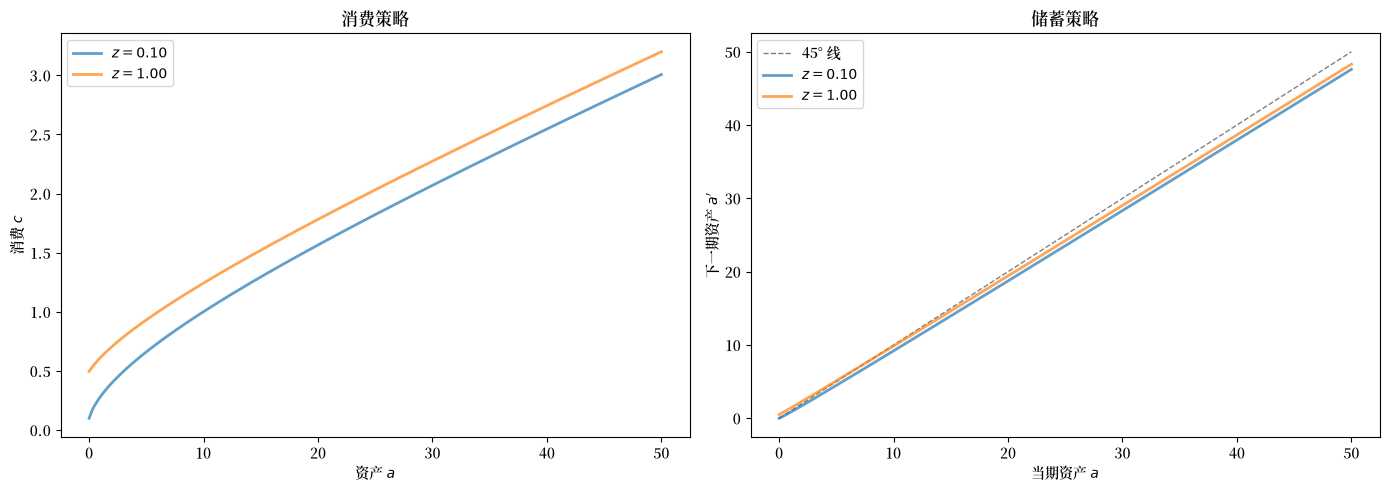

In [14]:
β, a_grid, z_grid, Π = household
r, w = prices

# 将消费策略转换为储蓄策略
income = w * z_grid[None, :] + (1 + r) * a_grid[:, None]
savings = income - σ_star

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 绘制消费策略
ax = axes[0]
for j, z in enumerate(z_grid):
    ax.plot(a_grid, σ_star[:, j], label=f'$z={z:.2f}$', lw=2, alpha=0.7)
ax.set_xlabel('资产 $a$')
ax.set_ylabel('消费 $c$')
ax.set_title('消费策略')
ax.legend()

# 绘制储蓄策略
ax = axes[1]
ax.plot(a_grid, a_grid, 'k--', lw=1, alpha=0.5, label='45° 线')
for j, z in enumerate(z_grid):
    ax.plot(a_grid, savings[:, j], label=f'$z={z:.2f}$', lw=2, alpha=0.7)
ax.set_xlabel('当期资产 $a$')
ax.set_ylabel("下一期资产 $a'$")
ax.set_title('储蓄策略')
ax.legend()

plt.tight_layout()
plt.show()

## 通过模拟计算总资本

我们不解析地计算马尔可夫链的平稳分布，而是通过模拟一个大的家庭横截面来计算总资本。

这种方法：

* 更灵活（适用于连续冲击、非线性策略等）
* 避免了存储和操作大型转移矩阵
* 在概念上更简单

模拟是完全向量化的：我们使用 `jax.lax.fori_loop` 同时推进所有家庭，通过逆 CDF 抽样绘制就业转移，并使用 `vmap` 化的插值来查找消费。

In [15]:
@partial(jax.jit, static_argnames=('num_households', 'num_periods'))
def simulate_cross_section(σ, household, prices, key,
                           num_households=50_000, num_periods=1_000):
    """
    向前模拟家庭面板，并返回资产和就业状态的
    终端横截面。
    """
    β, a_grid, z_grid, Π = household
    r, w = prices

    # Π 每一行的 CDF，用于转移的逆 CDF 抽样
    Π_cdf = jnp.cumsum(Π, axis=1)

    # 向量化的消费查找：为每个 z 沿资产对 σ 进行插值
    @jax.vmap
    def consume(a, j):
        return jnp.interp(a, a_grid, σ[:, j])

    # 初始条件：所有人都在网格中间，处于状态 0
    assets = jnp.full(num_households, a_grid[len(a_grid) // 2])
    z_idx = jnp.zeros(num_households, dtype=jnp.int32)

    def step(t, state):
        assets, z_idx, key = state
        key, subkey = jax.random.split(key)
        unif = jax.random.uniform(subkey, (num_households,))
        # 通过逆 CDF 进行马尔可夫转移
        z_idx = (unif[:, None] > Π_cdf[z_idx]).sum(axis=1).astype(jnp.int32)
        # 预算约束：消费，然后将资产带到下一期
        income = w * z_grid[z_idx] + (1 + r) * assets
        assets = income - consume(assets, z_idx)
        # 强制执行资产网格边界
        assets = jnp.clip(assets, a_grid[0], a_grid[-1])
        return assets, z_idx, key

    assets, z_idx, key = jax.lax.fori_loop(
        0, num_periods, step, (assets, z_idx, key)
    )
    return assets, z_idx

现在我们可以通过求解家庭问题并对模拟横截面上的资产取平均，来计算给定价格下的资本供给：

In [16]:
def capital_supply(household, prices, key,
                   num_households=50_000, num_periods=1_000):
    """
    通过模拟计算资本总供给。
    """
    σ = solve_household(household, prices)
    assets, _ = simulate_cross_section(
        σ, household, prices, key,
        num_households=num_households, num_periods=num_periods
    )
    return float(jnp.mean(assets))

让我们测试它：

In [17]:
household = create_household()
prices = Prices(r=0.01, w=1.0)
key = jax.random.PRNGKey(42)

with qe.Timer():
    K_supply = capital_supply(household, prices, key)

print(f"Capital supply: {K_supply:.4f}")

3.9751 seconds elapsed
Capital supply: 2.5863


## 计算均衡

现在我们可以通过找到使资本供给等于资本需求的资本存量来计算均衡。

给定 $K$，均衡映射 $G$ 计算：

1. 从厂商的一阶条件得到价格 $(r, w)$，
2. 给定这些价格下家庭的最优策略，
3. 通过模拟得到的资本总供给。

In [18]:
def G(K, firm, household, key,
      num_households=50_000, num_periods=1_000):
    """
    均衡映射 K -> 资本供给。
    """
    r = r_given_k(K, firm)
    w = r_to_w(r, firm)
    prices = Prices(r=r, w=w)
    return capital_supply(household, prices, key,
                          num_households=num_households,
                          num_periods=num_periods)

我们通过对超额需求 $K - G(K)$ 应用二分法来计算均衡。

我们向每次求值传递一个固定的随机 key，使得超额需求函数是确定性的，正如求根器所要求的那样。

In [19]:
def compute_equilibrium(firm, household, key,
                        K_min=4.0, K_max=12.0,
                        num_households=50_000, num_periods=1_000,
                        xtol=1e-2):
    """
    使用二分法计算均衡资本存量。
    """
    def excess_demand(K):
        return K - G(K, firm, household, key,
                     num_households=num_households,
                     num_periods=num_periods)

    return bisect(excess_demand, K_min, K_max, xtol=xtol)

让我们计算均衡：

In [20]:
firm = Firm()
household = create_household()
key = jax.random.PRNGKey(42)

with qe.Timer():
    K_star = compute_equilibrium(firm, household, key)

r_star = r_given_k(K_star, firm)
w_star = r_to_w(r_star, firm)

print(f"\nEquilibrium capital:       {K_star:.4f}")
print(f"Equilibrium interest rate: {r_star:.4f}")
print(f"Equilibrium wage:          {w_star:.4f}")

43.4983 seconds elapsed

Equilibrium capital:       8.1484
Equilibrium interest rate: 0.0309
Equilibrium wage:          1.3388


### 均衡可视化

让我们绘制供给和需求曲线：

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


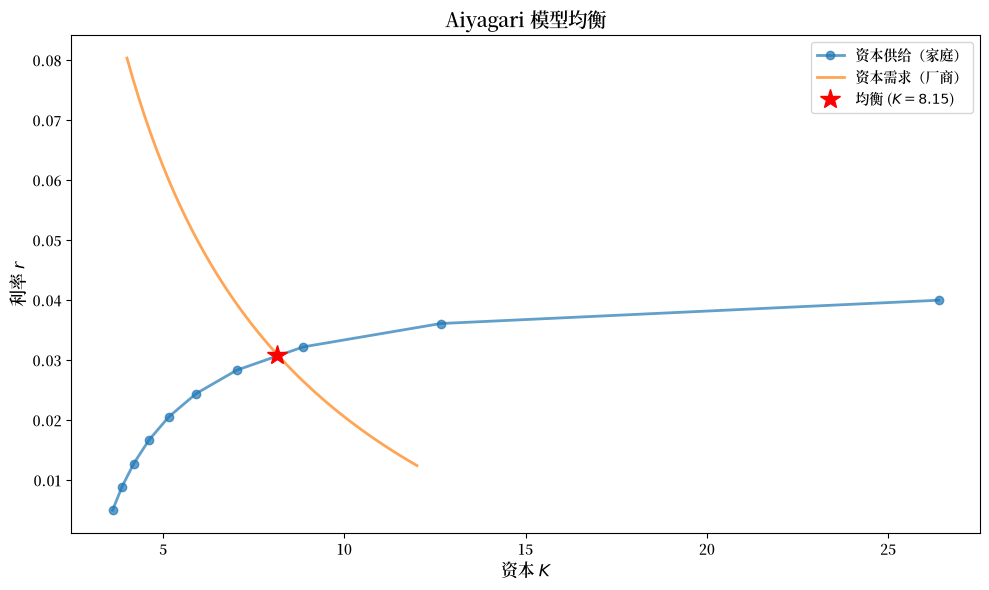

In [21]:
# 供给曲线：作为 r 的函数的家庭供给资本
r_vals = np.linspace(0.005, 0.04, 10)
K_supply_vals = []

for r in r_vals:
    w = r_to_w(r, firm)
    prices = Prices(r=r, w=w)
    K_supply_vals.append(capital_supply(household, prices, key))

# 需求曲线：作为 r 的函数的厂商需求资本
K_vals = np.linspace(4, 12, 50)
r_demand_vals = r_given_k(K_vals, firm)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(K_supply_vals, r_vals, 'o-', lw=2, alpha=0.7,
        label='资本供给（家庭）', markersize=6)
ax.plot(K_vals, r_demand_vals, lw=2, alpha=0.7,
        label='资本需求（厂商）')
ax.plot(K_star, r_star, 'r*', markersize=15, zorder=5,
        label=f'均衡 ($K={K_star:.2f}$)')

ax.set_xlabel('资本 $K$', fontsize=12)
ax.set_ylabel('利率 $r$', fontsize=12)
ax.set_title('Aiyagari 模型均衡', fontsize=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 财富分布

模拟方法的一个优势是我们可以轻松地检查财富分布。

我们重用在均衡价格下模拟的横截面：

In [22]:
prices_star = Prices(r=r_star, w=w_star)
σ_star = solve_household(household, prices_star)
assets_dist, z_dist = simulate_cross_section(σ_star, household, prices_star, key)

assets_dist = np.asarray(assets_dist)

我们使用 QuantEcon 的 `lorenz_curve` 和 `gini_coefficient` 来概括不平等程度：

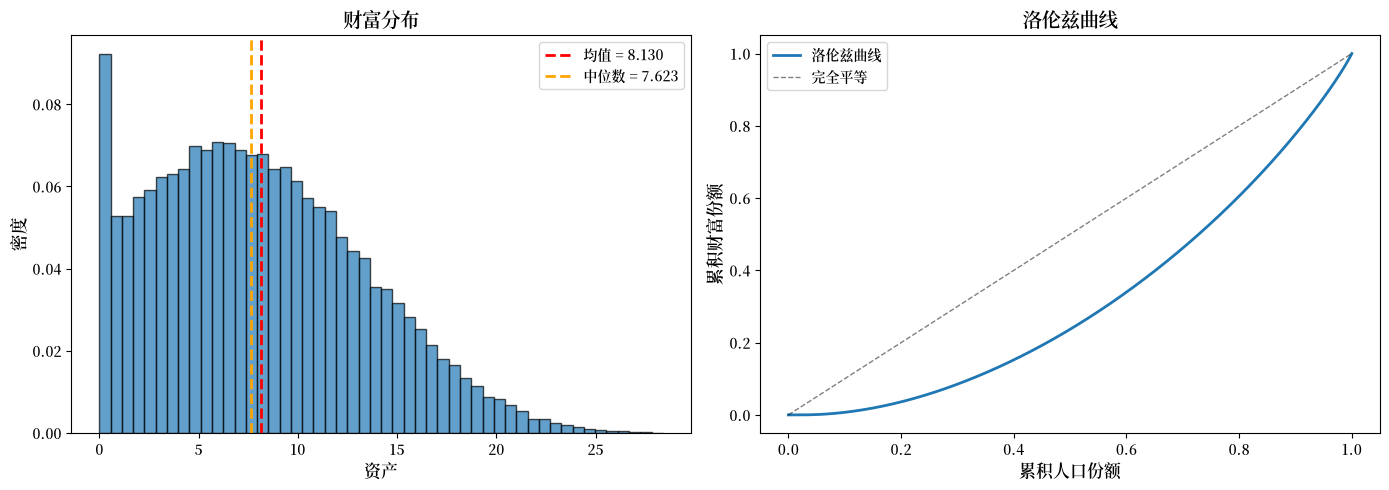


Gini coefficient: 0.3645


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 直方图
ax = axes[0]
ax.hist(assets_dist, bins=50, density=True, alpha=0.7, edgecolor='black')
ax.axvline(np.mean(assets_dist), color='red', linestyle='--', linewidth=2,
           label=f'均值 = {np.mean(assets_dist):.3f}')
ax.axvline(np.median(assets_dist), color='orange', linestyle='--', linewidth=2,
           label=f'中位数 = {np.median(assets_dist):.3f}')
ax.set_xlabel('资产', fontsize=12)
ax.set_ylabel('密度', fontsize=12)
ax.set_title('财富分布', fontsize=14)
ax.legend()

# 洛伦兹曲线
ax = axes[1]
cum_pop, cum_wealth = qe.lorenz_curve(assets_dist)
ax.plot(cum_pop, cum_wealth, lw=2, label='洛伦兹曲线')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='完全平等')
ax.set_xlabel('累积人口份额', fontsize=12)
ax.set_ylabel('累积财富份额', fontsize=12)
ax.set_title('洛伦兹曲线', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

gini = qe.gini_coefficient(assets_dist)
print(f"\nGini coefficient: {gini:.4f}")

## 总结与比较

本讲座演示了如何使用以下方法求解 Aiyagari 模型：

1. **内生网格法（EGM）** 用于家庭问题
   - 通过从欧拉方程向后推导，避免了昂贵的求根
   - 直接从边际效用计算消费
   - 比值函数迭代更高效

2. **模拟** 用于计算总资本
   - 模拟一个大的家庭横截面
   - 比解析平稳分布更灵活
   - 允许轻松计算财富不平等度量

### 与标准方法的比较

与 {doc}`标准 Aiyagari 讲座 <aiyagari>` 相比：

**优势：**

* EGM 避免了值函数迭代所需的求根
* 模拟更灵活（适用于连续冲击、非线性策略）
* 易于计算分布统计量（基尼系数、百分位数等）
* 该方法更容易扩展到更复杂的模型

**劣势：**

* 模拟需要大量家庭以保证准确性
* 均衡计算受蒙特卡洛噪声影响
* 它不如解析平稳分布精确

### 扩展

该框架可以轻松扩展到：

* 连续收入冲击（例如，对数正态分布）
* 更复杂的偏好设定
* 总量冲击和异质性主体新凯恩斯主义（HANK）模型
* 具有年龄相关策略的生命周期模型

## 练习

```{exercise}
:label: aiyagari_egm_ex1

比较 EGM 与 {doc}`标准 Aiyagari 讲座 <aiyagari>` 中使用的
值函数迭代方法的速度和准确性。

1. 在相同价格下用两种方法求解家庭问题。
2. 对两种方法计时并比较得到的策略。
3. 哪种方法更快？策略是否接近？
```

```{exercise}
:label: aiyagari_egm_ex2

研究财富分布如何随贴现因子 $\beta$ 变化。

1. 计算 $\beta \in \{0.94, 0.95, 0.96, 0.97\}$ 的均衡。
2. 对于每个 $\beta$，计算并绘制财富分布。
3. 基尼系数如何随 $\beta$ 变化？
4. 解释其经济直觉。
```

```{exercise}
:label: aiyagari_egm_ex3

本讲座介绍的模拟方法使用固定的期数。研究这一选择的影响：

1. 将 `num_periods` 从 200 变化到 2000。
2. 对于每个值，用不同的随机 key 多次计算平均资产。
3. 绘制资本估计的标准差作为 `num_periods` 的函数。
4. 准确性与计算成本之间的权衡是什么？
```

```{exercise}
:label: aiyagari_egm_ex4

扩展模型以包含第三种就业状态（例如，失业、兼职、全职）：

1. 建立一个具有适当转移概率的 3 状态马尔可夫链。
2. 为每个状态定义收入水平。
3. 重新计算均衡。
4. 额外的异质性如何影响财富分布？
```